In [1]:
import torch

In [2]:
net = torch.nn.Conv2d(1, 16, 3, 4, (3 - 1) // 2)
# 1 is channels in
# 16 is channels out
# 3 is kernel size
# 4 is stride [1 is no stride]
# (kernal size - 1) // 2 is padding 


In [3]:
x = torch.randn(1, 1, 28, 28)
print(x.shape)

torch.Size([1, 1, 28, 28])


In [4]:
y = net(x)
print(y.shape)

torch.Size([1, 16, 7, 7])


In [16]:
class ConvNet(torch.nn.Module):
    def __init__(self, layers=[16, 32, 64], kernel_size=3, stride=1):
        super().__init__()
        cnn_layers = []
        c1 = 1 #1 dimensional input
        for c2 in layers:
            cnn_layers.append(torch.nn.Conv2d(c1, c2, kernel_size, stride, (kernel_size - 1) // 2)) #convolution layer
            cnn_layers.append(torch.nn.ReLU()) #nonlinear layer
            c1 = c2
        cnn_layers.append(torch.nn.Conv2d(c1, 1, kernel_size=1)) #classifier
        ##cnn_layers.append(torch.nn.AdaptiveAvgPool2d(1)) #averages all the outputs together
        self.network = torch.nn.Sequential(*cnn_layers)

    def forward(self, x):
        return self.network(x)


net = ConvNet(stride=2)
print(net)
net(x).shape

ConvNet(
  (network): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(64, 1, kernel_size=(1, 1), stride=(1, 1))
  )
)


torch.Size([1, 1, 4, 4])

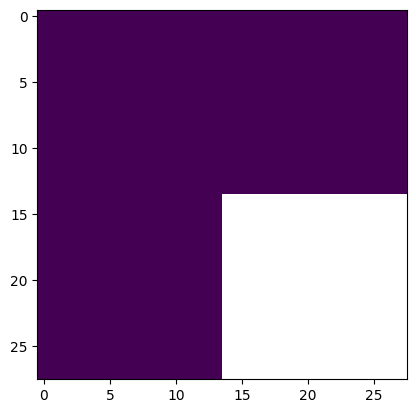

In [28]:
from matplotlib import pyplot as plt

x = torch.randn(1, 1, 28, 28, requires_grad=True)
##x[0, 0, 10, 10] = float('NaN')
net = ConvNet(stride = 3)
y = net(x)
z = y.new_zeros(y.shape)

z[0, 0, z.shape[2] // 2, z.shape[3] // 2] = float("NaN")

(y*z).sum().backward()



plt.imshow(x.grad[0, 0].detach().numpy())

##z = y.new_zeros(y.shape)
##z[0, 0, z.shape[2] // 2, z.shape[3] // 2] = float("NaN")
##f, ax = plt.subplots(1, 2)
##ax[0].imshow(z[0, 0].detach().numpy())

##(y * z).sum().backward()


##ax[1].imshow(x.grad[0, 0].detach().numpy())